# Computational Modeling of Drug Diffusion in Tissue

## Research Question
How does drug concentration change as it diffuses deeper into biological tissue over time?

## Significance
Understanding how drugs penetrate tissue is important in chemotherapy and targeted drug delivery. 
If a drug does not diffuse deeply enough into a tumor, inner cancer cells may survive treatment.

This project models drug concentration as a function of depth using diffusion principles.

## Mathematical Model
Drug diffusion can be described using the diffusion equation.

For a simple case, the concentration profile is approximated as:

$$
C(x,t) = e^{-\frac{x^2}{4Dt}}
$$

where:

- $C(x,t)$ = concetration at depth $x$ and time $t$
- $D$ = diffusion coefficient
- $x$ = depth of tissue
- $t$ = time

## Experiment 1: Baseline Drug Diffusion in Tissue

### Purpose
To visualize the concentration profile of a drug diffusing into tissue at a single time point.

### Method
The diffusion equation is evaluated with diffusion coefficient $D = 0.5$ at time $t = 1$.

### Code :

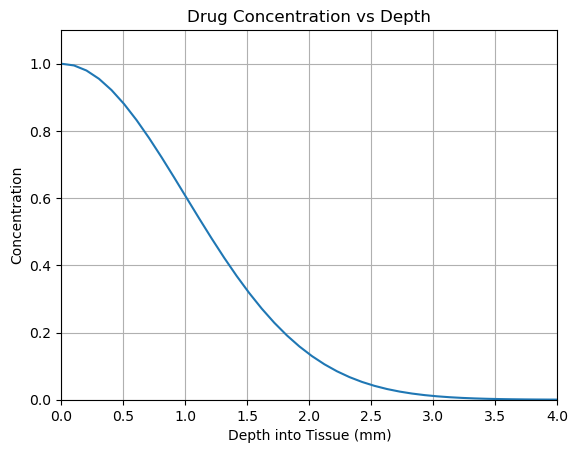

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion coefficient (how quickly molecules spread throughout the tissue)
D = 0.5

# Time after drug administration (seconds)
t = 1

# Depth into tissue from surface (mm)
x = np.linspace(0, 10, 100)

# Compute concentration profile using diffusion equation
C = np.exp(-(x**2) / (4 * D * t))

# Plot
plt.plot(x, C)
plt.title("Drug Concentration vs Depth")
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Concentration")
plt.xlim(0,4)
plt.ylim(0,1.1)
plt.grid()

plt.show()

### Observations

The graph shows that drug concentration decreases rapidly as depth into tissue increases.

Key observations:
- Concentration is highest at the surface ($x$ = $0$ mm), where the drug is applied.
- As depth increases, concentration declines smoothly following an exponential decay pattern.
- The steepest gradient occurs near the surface, indicating the strongest diffusion flux in this region.
- Beyond approximately $3$ mm, the concentration approaches near-zero values.

### Interpretation

This suggests that drugs delivered from a surface source may have limited ability to reach deeper regions of tissue within short time scales.

## Experiment 2: Effect of Time on Drug Diffusion

### Purpose
To observe how the drug concentration profile changes as diffusion progresses over time.

### Method
The diffusion model is evaluated for multiple time values:
$t$ = $0.5$, $1$, $2$, $5$, and $10$ seconds.

### Code :

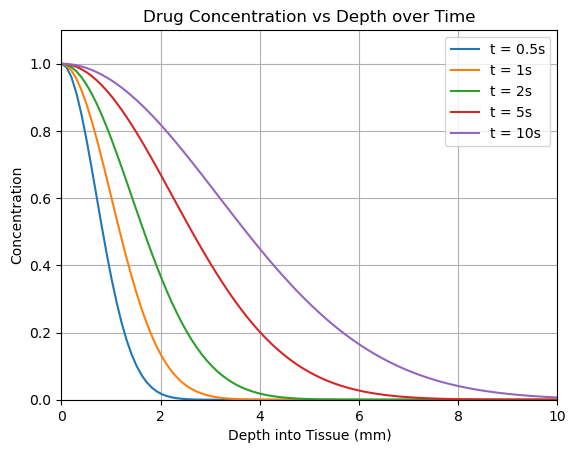

In [2]:
import numpy as np
import matplotlib.pyplot as plt

D = 0.5
x = np.linspace(0, 10, 100)

times = [0.5, 1, 2, 5, 10]

for t in times:
    C = np.exp(-(x**2) / (4 * D * t))
    plt.plot(x, C, label = f't = {t}s')

# Plot
plt.title("Drug Concentration vs Depth over Time")
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Concentration")
plt.xlim(0,10)
plt.ylim(0,1.1)
plt.legend()
plt.grid()

plt.show()

### Observations

The graph shows how the drug concentration profile evolves as diffusion progresses over time.

Key observations:
- At early times (e.g., $t$ = $0.5$ s), drug penetration is shallow and concentration drops sharply with depth.
- As time increases, the concentration profile spreads deeper into the tissue.
- The slope near the surface becomes less steep over time, indicating reduced concentration gradients.
- Although penetration depth increases, concentration still decreases significantly with depth at all time points.

### Interpretation

These results demonstrate that diffusion is a time-dependent process. Increasing time allows the drug to penetrate deeper into tissue, but concentration remains highest near the surface, suggesting that prolonged exposure may be necessary to reach deeper regions effectively.

## Experiment 3 : Effect of Diffusion Coefficient

### Purpose
To investigate how the diffusion coefficient affects the rate at which drugs spread through tissue.

### Method
The diffusion model is simulated using several diffusion coefficients representing slow and fast molecular movement.

### Code :

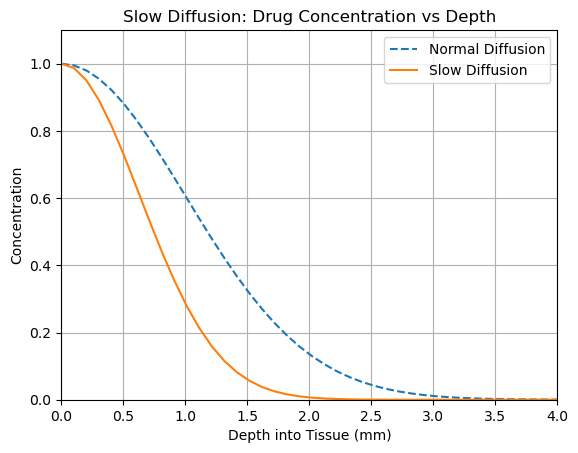

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion coefficents
D_slow = 0.2
D_normal = 0.5


t = 1
x = np.linspace(0, 10, 100)

# Concentration profiles using diffusion equation
C_normal = np.exp(-(x**2) / (4 * D_normal * t))
C_slow = np.exp(-(x**2) / (4 * D_slow * t))

# Plot
plt.plot(x, C_normal, label='Normal Diffusion', linestyle='--')
plt.plot(x, C_slow, label='Slow Diffusion')
plt.title("Slow Diffusion: Drug Concentration vs Depth")
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Concentration")
plt.xlim(0, 4)
plt.ylim(0, 1.1)
plt.legend()
plt.grid()

plt.show()

### Observations

The graph compares concentration profiles for different diffusion coefficients.

Key observations:
- Higher diffusion coefficients produce flatter concentration curves and deeper penetration.
- Lower diffusion coefficients result in steeper gradients and limited penetration depth.
- For small diffusion coefficients, concentration approaches zero at much shallower depths.
- Differences between curves become more pronounced at larger depths.

### Interpretation

These results indicate that tissue properties and molecular characteristics strongly influence drug penetration. Drugs with higher diffusivity—or tissues with less structural resistance—allow deeper and more uniform distribution. 

## Experiment 4 : Drug Diffusion in Layered Tissue

### Purpose
To model drug diffusion through tissues with different structural properties.

### Method
The model simulates two layers of tissue with different diffusion coefficients, representing heterogenous biological tissue.

### Code :

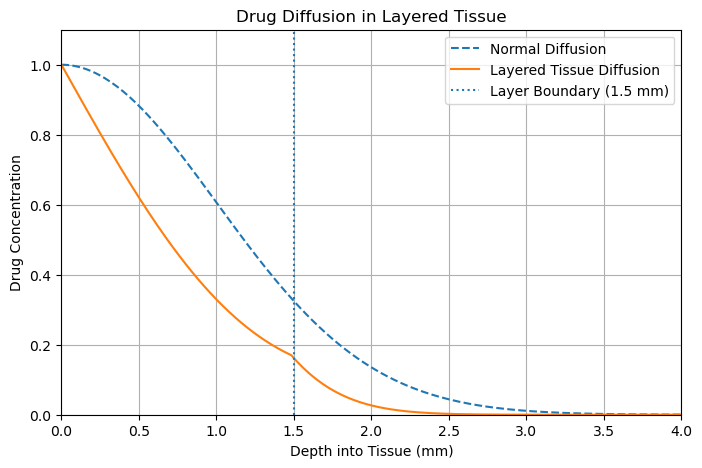

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 10          # tissue depth (mm)
T = 1           # total time (s)
nx = 500        # number of depth points
nt = 5000       # time steps

dx = L / nx
dt = T / nt

x = np.linspace(0, L, nx)

# Diffusion coefficients
D1 = 0.5
D2 = 0.2
boundary = 1.5

# Layered D(x)
D = np.where(x <= boundary, D1, D2)

# Initial concentration: drug applied at surface
C = np.zeros(nx)
C[0] = 1

# Time evolution (finite difference)
for n in range(nt):
    C_new = C.copy()
    
    for i in range(1, nx-1):
        C_new[i] = C[i] + dt/dx**2 * (
            D[i+1]*(C[i+1]-C[i]) - D[i]*(C[i]-C[i-1])
        )
    
    C = C_new
    C[0] = 1

C_1 = np.exp(-(x**2) / (4*D1*T))

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, C_1, label="Normal Diffusion", linestyle='--')
plt.plot(x, C, label="Layered Tissue Diffusion")
plt.axvline(x=boundary, linestyle=':', label="Layer Boundary (1.5 mm)")

plt.title("Drug Diffusion in Layered Tissue")
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Drug Concentration")

plt.xlim(0,4)
plt.ylim(0,1.1)

plt.legend()
plt.grid()

plt.show()

### Observations

The graph shows drug diffusion across two tissue layers with different diffusion coefficients.

Key observations:
- Concentration decreases smoothly in the first layer where diffusion is faster.
- At the layer boundary ($1.5$ mm), the slope of the concentration curve changes noticeably.
- In the second layer, where the diffusion coefficient is lower, concentration declines more steeply.
- Drug penetration into the slower-diffusing layer is significantly reduced.

### Interpretation

This suggests that heterogeneous tissue structure can significantly limit drug penetration.
Regions with lower diffusion coefficients may prevent therapeutic concentrations from reaching deeper cells.

## Experiment 5 : Drug Diffusion with Molecular Binding

### Purpose
To simulate the effect of drug molecules binding to tissue components, which reduces the free concentration available to diffuse deeper.

### Method
A binding/decay term is added to the diffusion model to represent drug interaction with tissue molecules.

### Code :

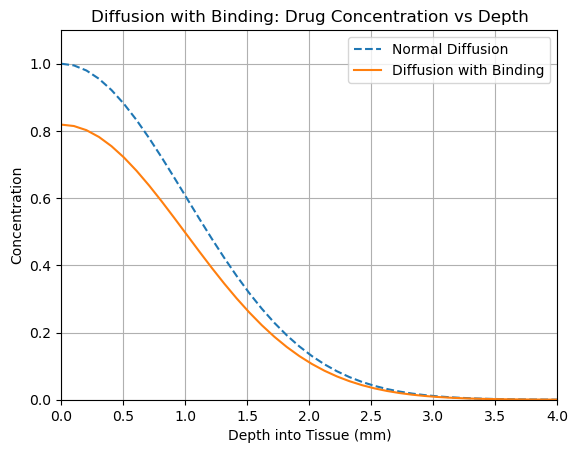

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = 1
D = 0.5
x = np.linspace(0, 10, 100)

# Binding rate
k_bind = 0.2

# Normal diffusion
C_normal = np.exp(-(x**2) / (4 * D * t))

# Diffusion with binding
C_bind = np.exp(-(x**2) / (4 * D * t)) * np.exp(-k_bind * t)

# Plot
plt.plot(x, C_normal, label='Normal Diffusion', linestyle='--')
plt.plot(x, C_bind, label='Diffusion with Binding')
plt.title("Diffusion with Binding: Drug Concentration vs Depth")
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Concentration")
plt.xlim(0,4)
plt.ylim(0,1.1)
plt.legend()
plt.grid()

plt.show()

### Observations

The graph shows how drug concentration changes when molecular binding or decay is included in the model.

Key observations:
- Concentration decreases more rapidly compared to the pure diffusion case.
- The overall magnitude of concentration is reduced at all depths.
- Penetration depth is smaller when binding effects are present.
- The decay effect becomes more significant at longer times.

### Interpretation

These results indicate that biochemical interactions within tissue—such as binding to proteins or cellular uptake—can substantially reduce the amount of free drug available to diffuse. This highlights the importance of accounting for drug-tissue interactions when predicting therapeutic effectiveness.

## Overall Analysis: What Do All 5 Experiments Tell Us?

Across all five experiments, the results consistently show that drug diffusion in tissue is highly dependent on both physical and biological factors. Experiment 1 establishes the baseline behavior: drug concentration decreases rapidly with depth, following an exponential decay pattern. This demonstrates that diffusion alone naturally limits how far a drug can penetrate within a short time frame. Experiment 2 builds on this by showing that increasing time allows the drug to spread deeper into tissue, but the improvement in penetration is gradual and does not eliminate the steep concentration gradient.

Experiment 3 reveals that the diffusion coefficient is a critical parameter in determining drug effectiveness. Higher diffusion coefficients result in deeper and more uniform drug distribution, while lower coefficients significantly restrict penetration. Experiment 4 adds realism by introducing layered tissue, showing that structural heterogeneity can create barriers to diffusion. The change in slope at the layer boundary highlights how regions with lower diffusivity can limit drug transport. Finally, Experiment 5 shows that biochemical interactions such as binding or decay further reduce the amount of free drug available, decreasing both overall concentration and penetration depth.

Together, these experiments demonstrate that drug delivery in biological tissue is not governed by diffusion alone, but by a combination of time, tissue structure, and molecular interactions. Even under ideal conditions, diffusion leads to uneven drug distribution, and real biological factors can further limit effectiveness.


### Clinical/Real-World Implications

These findings have important implications for drug delivery in medical treatments such as chemotherapy. In solid tumors, poor diffusion, dense tissue structure, and drug binding can prevent therapeutic concentrations from reaching deeper cancer cells. This may lead to incomplete treatment and contribute to drug resistance. As a result, effective therapies may require strategies beyond simple diffusion, such as targeted drug delivery systems, higher dosing over time, or methods that improve tissue penetration.